In [3]:
#import packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

## Subject Parameters

In [ ]:
BASE_DIR     = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT      = 102311
TASK         = "EMOTION"     # 또는 "GAMBLING"
PHASE        = "LR"          # "LR" 또는 "RL"

In [5]:
aal = datasets.fetch_atlas_aal()
aal_img    = aal.maps    # AAL atlas NIfTI 경로
aal_labels = aal.labels  # ROI 이름 리스트

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [6]:
masker    = NiftiLabelsMasker(
    labels_img       = aal_img,
    standardize      = "zscore_sample",
    detrend          = True,
    low_pass         = None,
    high_pass        = None,
    t_r              = 0.72,
    resampling_target = "data"
)

In [7]:
def make_paths(subject, task, phase="LR"):
    img_path = BASE_DIR / f"{subject:06d}/MNINonLinear/Results/tfMRI_{task}_{phase}/tfMRI_{task}_{phase}.nii.gz"
    ev_dir   = img_path.parent / "EVs"
    return img_path, ev_dir

In [8]:
def get_residual(img_path: Path, ev_dir: Path):
    """
    EVs 폴더 내의 *.txt 파일들을 건너뛰기 로직과 함께 읽어서
    onset/duration 정보를 모은 뒤, FirstLevelModel로 GLM을 수행한 후
    residual 4D 이미지를 반환합니다.
    """
    events = []

    for ev_file in sorted(ev_dir.glob("*.txt")):
        # 1) 순수히 숫자가 아닌 파일은 건너뛰기
        try:
            data = np.loadtxt(ev_file)
        except Exception:
            continue

        # 2) 빈 파일 혹은 숫자가 0개라면 건너뜀
        if data.size == 0:
            continue

        # 3) 1차원 배열(단일 행)인 경우, 열 개수 확인
        if data.ndim == 1:
            if data.shape[0] < 2:
                # onset/duration 정보를 담기 어렵다면 건너뜀
                continue
            data = data.reshape(1, -1)

        # 4) 2차원 배열(여러 행)인 경우, 열 개수가 2 또는 3인지 확인
        if data.ndim == 2:
            n_cols = data.shape[1]
            if n_cols not in (2, 3):
                continue
        else:
            # ndim이 0 또는 3 이상이면 건너뜀
            continue

        # 5) 최종적으로 data가 (N_events, 2) 혹은 (N_events, 3) 모양으로 보장됨
        if data.shape[1] == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # data.shape[1] == 2
            onset_arr, duration_arr = data.T

        for o, d in zip(onset_arr, duration_arr):
            events.append({
                "onset":      float(o),
                "duration":   float(d),
                "trial_type": ev_file.stem
            })

    # 만약 events 리스트가 비어 있으면 None 반환
    if not events:
        return None

    # 이벤트가 모였다면 DataFrame으로 정리하고 GLM → residual 반환
    events_df = pd.DataFrame(events, columns=["onset", "duration", "trial_type"])
    fmri_img  = image.load_img(str(img_path))
    model     = FirstLevelModel(
        t_r              = 0.72,
        drift_model      = "polynomial",
        standardize      = False,
        minimize_memory  = False
    ).fit(fmri_img, events=events_df)

    return model.residuals[0]  # list이므로 첫 번째 residual 4D 이미지 반환

In [9]:
def sliding_window_dist(ts: np.ndarray, win: int, step: int) -> np.ndarray:
    """
    ts: (T, P) shaped array, T = time points, P = number of ROIs
    win: window length in TRs
    step: sliding step in TRs

    반환값: (n_windows, P, P) shaped array of 1 - |correlation| distance matrices
    """
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P        = ts.shape
    n_windows   = (T - win) // step + 1
    out         = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, start in enumerate(range(0, T - win + 1, step)):
        segment      = ts[start : start + win]
        corr_matrix  = connectivity.fit_transform([segment])[0]
        dist_matrix  = 1.0 - np.abs(corr_matrix)
        out[idx]     = dist_matrix

    return out

In [11]:
img_path, ev_dir = make_paths(SUBJECT, TASK, PHASE)
print(f"Loading {TASK} {PHASE} run from: {img_path}")

Loading EMOTION LR run from: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\102311\MNINonLinear\Results\tfMRI_EMOTION_LR\tfMRI_EMOTION_LR.nii.gz


In [12]:
resid_img = get_residual(img_path, ev_dir)
if resid_img is None:
    raise RuntimeError(f"No usable EV files found for {TASK} {PHASE} run.")

c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [14]:
ts_resid = masker.fit_transform(resid_img)   # shape = (T, n_rois)
T, n_rois = ts_resid.shape
print(f"Extracted time-series shape: {ts_resid.shape}")

Extracted time-series shape: (176, 116)


## Window Parameters

In [ ]:
WINDOW_SIZE  = 18            # TR 단위
STEP_SIZE    = 2             # TR 단위

In [15]:
TR = 0.72
total_duration = T * TR
print(f"fMRI 총 길이: {T} TR ≈ {total_duration:.2f}초")


fMRI 총 길이: 176 TR ≈ 126.72초


In [ ]:
def load_task_blocks(ev_dir, task):
    """
    ev_dir: EV 파일들이 들어있는 디렉터리 경로 (예: "C:/HCP/100206/tfMRI_EMOTION_LR/EVs")
    task: "emotion" 또는 "gambling"
    
    반환: [(label, onset_sec, duration_sec), ...] 형태의 리스트 (onset 기준 오름차순 정렬)
    """
    blocks = []
    
    if task.lower() == "emotion":
        # Emotion: fear.txt, neut.txt → duration = 18.0
        mapping = {
            "fear":    "fear.txt",
            "neutral": "neut.txt"
        }
        dur = 18.0
        for label, fname in mapping.items():
            path = os.path.join(ev_dir, fname)
            if not os.path.isfile(path):
                raise FileNotFoundError(f"Emotion EV 파일이 없습니다:\n  {path}")
            onsets = np.loadtxt(path)[:, 0]
            for t in onsets:
                blocks.append((label, float(t), dur))
    
    elif task.lower() == "gambling":
        # Gambling: loss.txt, neut_event.txt, win.txt → duration = 28.0
        mapping = {
            "loss":    "loss.txt",
            "neutral": "neut_event.txt",
            "win":     "win.txt"
        }
        dur = 28.0
        for label, fname in mapping.items():
            path = os.path.join(ev_dir, fname)
            if not os.path.isfile(path):
                raise FileNotFoundError(f"Gambling EV 파일이 없습니다:\n  {path}")
            onsets = np.loadtxt(path)[:, 0]
            for t in onsets:
                blocks.append((label, float(t), dur))
    
    else:
        raise ValueError(f"지원되지 않는 task 이름: {task!r}. 'emotion' 또는 'gambling'만 허용됩니다.")
    
    # onset 기준 오름차순 정렬
    blocks.sort(key=lambda x: x[1])
    return blocks

In [34]:
emotion_ev_dir = f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset/{SUBJECT:06d}/MNINonLinear/Results/tfMRI_{TASK}_LR/EVs"
emotion_blocks = load_task_blocks(emotion_ev_dir, "emotion")
print(">> Emotion blocks:")
for lbl, onset, dur in emotion_blocks:
    print(f"{lbl:8s} | onset = {onset:7.3f} s | dur = {dur:.1f} s")

>> Emotion blocks:
neutral  | onset =  10.996 s | dur = 18.0 s
fear     | onset =  32.067 s | dur = 18.0 s
neutral  | onset =  53.139 s | dur = 18.0 s
fear     | onset =  74.210 s | dur = 18.0 s
neutral  | onset =  95.281 s | dur = 18.0 s
fear     | onset = 116.353 s | dur = 18.0 s


In [43]:
emotion_blocks

[('neutral', 10.996, 18.0),
 ('fear', 32.067, 18.0),
 ('neutral', 53.139, 18.0),
 ('fear', 74.21, 18.0),
 ('neutral', 95.281, 18.0),
 ('fear', 116.353, 18.0)]

In [35]:
# ───────────────
# 1. Compute block TR range
# ───────────────
events = []
for label, onset, duration in emotion_blocks:

    start_tr = int(np.floor(onset / TR))
    end_tr   = int(np.ceil((onset + duration) / TR)) - 1
    events.append({
        "trial_type": label,
        "onset_sec":  onset,
        "duration_s": duration,
        "start_tr":   start_tr,
        "end_tr":     end_tr
    })

ev_df = pd.DataFrame(events)
print("\n=== BLOCKS  ===")
print(ev_df[["trial_type", "start_tr", "end_tr"]].to_string(index=False))

# ───────────────
# 2. Sliding Window Labeling 
# ───────────────

n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1

window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print("\n=== WINDOW LABELS ===")
print(win_df.to_string(index=False))


=== BLOCKS  ===
trial_type  start_tr  end_tr
   neutral        15      40
      fear        44      69
   neutral        73      98
      fear       103     128
   neutral       132     157
      fear       161     186

=== WINDOW LABELS ===
 window_index  center_tr block_label
            0         12    no_event
            1         15     neutral
            2         18     neutral
            3         21     neutral
            4         24     neutral
            5         27     neutral
            6         30     neutral
            7         33     neutral
            8         36     neutral
            9         39     neutral
           10         42    no_event
           11         45        fear
           12         48        fear
           13         51        fear
           14         54        fear
           15         57        fear
           16         60        fear
           17         63        fear
           18         66        fear
           19    

<Figure size 1200x400 with 0 Axes>

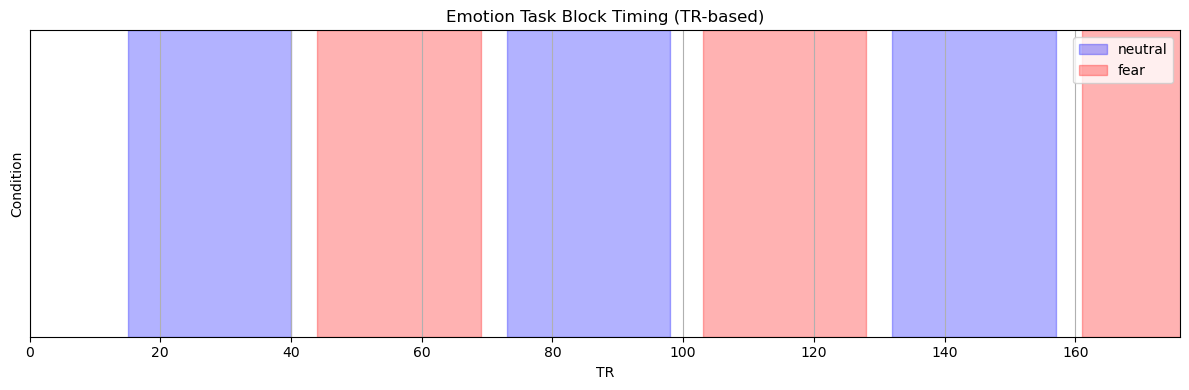

In [36]:
# Convert to TR-based onsets 
corrected_blocks = []
for label, onset, duration in emotion_blocks:

    start_tr = int(onset // TR)
    end_tr   = int((onset + duration) // TR)
    corrected_blocks.append((label, start_tr, end_tr))

# Plot
plt.figure(figsize=(12, 4))
for label, start_tr, end_tr in corrected_blocks:
    color = 'red' if label == 'fear' else 'blue'
    alpha = 0.3
    label_name = label if label not in plt.gca().get_legend_handles_labels()[1] else None
    plt.axvspan(start_tr, end_tr, color=color, alpha=alpha, label=label_name)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Emotion Task Block Timing (TR-based)")
plt.xlim(0, 176)
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
dist_tensor = sliding_window_dist(ts_resid, WINDOW_SIZE, STEP_SIZE)
print(f"Distance tensor shape: {dist_tensor.shape}")

Distance tensor shape: (51, 116, 116)


In [10]:
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts")
OUT_DIR.mkdir(exist_ok=True)

In [38]:
out_path = OUT_DIR / f"{SUBJECT}_{TASK}_{PHASE}_AAL_resid_abs_dist.npy"
np.save(out_path, dist_tensor)
print(f"Saved → {out_path}")

Saved → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\tfMRI_ts\102311_emotion_dist\102311_EMOTION_LR_AAL_resid_abs_dist.npy


In [39]:
OUT_DIR = Path(f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_emotion_dist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [40]:
for i, mat in enumerate(dist_tensor):
    # 파일명 예시: rs100206_dist_matrix_000.txt, rs100206_dist_matrix_001.txt, ...
    file_path = OUT_DIR / f"emotion{SUBJECT}_dist_matrix_{i:03d}.txt"
    np.savetxt(file_path, mat, fmt='%.6f')
    # (원하는 경우, delimiter='\t' 등을 추가할 수 있습니다)
    # 예: np.savetxt(file_path, mat, fmt='%.6f', delimiter='\t')
    #print(f"Saved → {file_path}")

In [41]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_emotion_dist/emotion{SUBJECT:06d}_dist_matrix_000.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (116, 116)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 116 * 116 = {116 * 116}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (116, 116)
Number of entries    : 13456
Expected entries     : 116 * 116 = 13456
Min value            : 0.0000
Max value            : 1.0000
Any NaNs             : False
Any Infs             : False


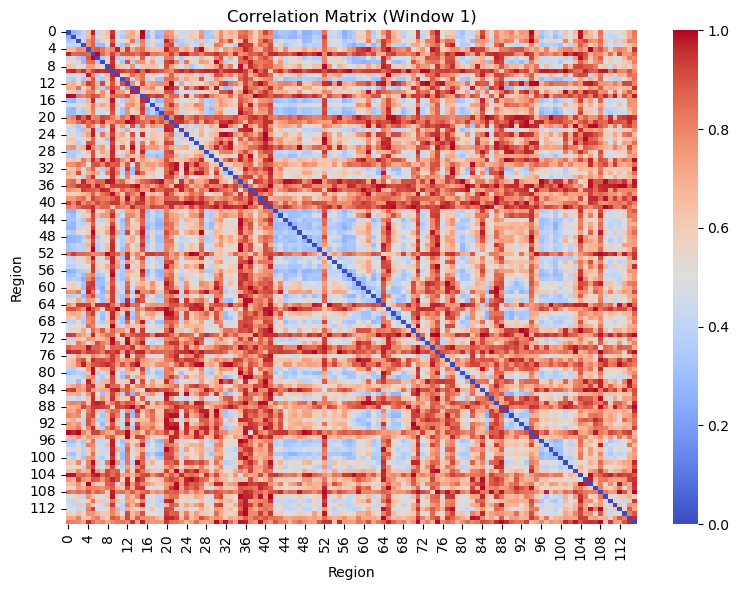

In [42]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(dist_tensor[0], cmap='coolwarm', vmin=0, vmax=1)
plt.title("Distance Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()